In [2]:
import pandas as pd 
import numpy as np
from pykalman import KalmanFilter # Smoothing data, could be interesting for future work
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
#Notes
"""
I wonder if we using the ML forecasting to get the data then forecast 
Determine our forecast against the streets, then balance our position using the key criterion
To bet the optimal amount according to the Kelly Criterion

"""

'\nI wonder if we using the ML forecasting to get the data then forecast \nDetermine our forecast against the streets, then balance our position using the key criterion\nTo bet the optimal amount according to the Kelly Criterion\n\n'

In [4]:
tickers = ['SPY', 'XLG', 'DIA', '^OEX'] #Spy is the benchmark
#I want to get today's date 
today = pd.Timestamp.today().strftime('%Y-%m-%d')
print(f"Today's date: {today}")
data = yf.download(tickers, start="2020-01-01", end=today)
#data.dropna(inplace=True)
df = data['Close'].dropna(how = 'all')
df

Today's date: 2026-02-05


/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_1686/2466266739.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end=today)
[*********************100%***********************]  4 of 4 completed


Ticker,DIA,SPY,XLG,^OEX
Date,,,,
2020-01-02,258.484375,297.698975,22.283434,1458.130005
2020-01-03,256.424561,295.444733,22.114689,1446.479980
2020-01-06,257.015533,296.571899,22.213675,1452.810059
2020-01-07,255.905151,295.737946,22.115625,1447.359985
2020-01-08,257.391785,297.314117,22.265520,1455.489990
...,...,...,...,...
2026-01-29,490.209991,694.039978,59.009998,3441.239990
2026-01-30,489.029999,691.969971,59.009998,3437.189941
2026-02-02,494.029999,695.409973,59.279999,3454.729980


Ticker
DIA     0.200358
SPY     0.206766
XLG     0.216700
^OEX    0.212973
dtype: float64
30-Day Vol: Ticker
DIA     0.110876
SPY     0.096465
XLG     0.106872
^OEX    0.100245
dtype: float64


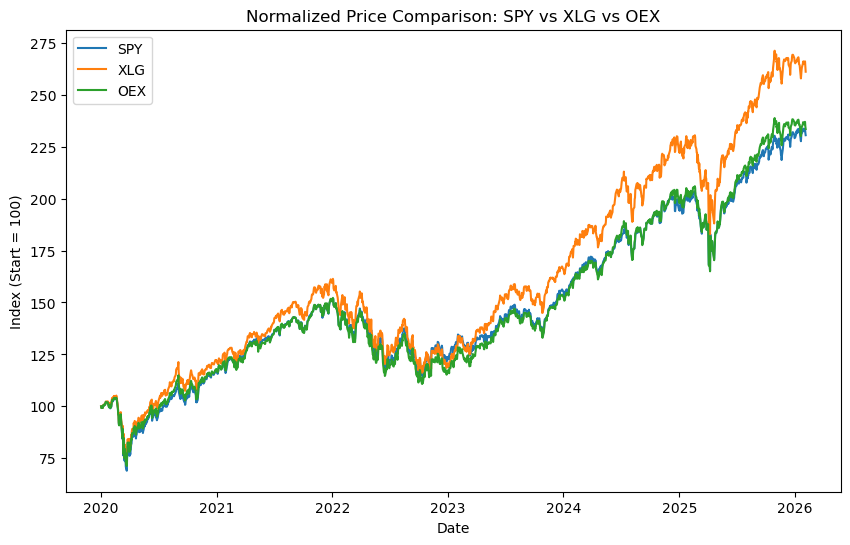

In [13]:
#Taking Percent Return
returns = np.log(df / df.shift(1)).dropna()
print(returns.std()*np.sqrt(252))
print(f"30-Day Vol: {returns.tail(30).std()*np.sqrt(252)}")
returns.head()
prices_norm = df[tickers] / df[tickers].iloc[0] * 100

plt.figure(figsize=(10, 6))
plt.plot(prices_norm.index, prices_norm['SPY'], label='SPY')
plt.plot(prices_norm.index, prices_norm['XLG'], label='XLG')
plt.plot(prices_norm.index, prices_norm['^OEX'], label='OEX')
plt.legend()
plt.title('Normalized Price Comparison: SPY vs XLG vs OEX')
plt.xlabel('Date')
plt.ylabel('Index (Start = 100)')
plt.show()
#XLG is where we are putting our money

In [6]:
prices = df['SPY']

kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=prices.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

state_means, _ = kf.filter(prices.values)
kalman_series = pd.Series(state_means.flatten(), index=prices.index)

ma30 = prices.rolling(30).mean()

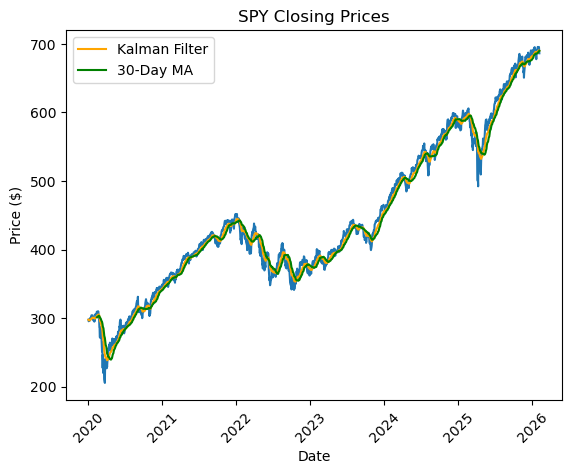

In [7]:
plt.plot(df.index, df['SPY'])
plt.plot(kalman_series.index, kalman_series, label='Kalman Filter', color='orange')
plt.plot(ma30.index, ma30, label='30-Day MA', color='green')
plt.legend()
plt.title('SPY Closing Prices')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')
plt.show()